In [1]:
# 필요한 함수들 정의
from tqdm import tqdm
import time
import numpy as np
import random
import hnswlib
from tqdm import tqdm
import time
import json
import os 
# 데이터셋 불러오는 블록

dataset_name ="sift1m"
# dataset_name ="HnM"
# dataset_name ="ArXiv"
dataset_name ="mtg-40K"

num_attribute = 12
cardinality = [12] * num_attribute
# distribution = "random"
distribution = "zipf"

# sort_hardness = "Hardness"
# sort_hardness = "Pre_Hardness"
sort_hardness = "Post_Hardness"

# sort_hardness = "mul"
# sort_hardness = "sum"
# sort_hardness = "harmonic"
# sort_hardness = "geometric"
# sort_hardness = "weighted_sum"; weight_param = [0.5,0.5]




# sort_hardness = "selectivity"
# sort_hardness = "correlation"
# sort_hardness = "select_corr_combine"


##################################################################################################
if sort_hardness == "selectivity" or sort_hardness == "correlation" or sort_hardness == "select_corr_combine":
    baseline = 1
else:
    baseline = 0

if dataset_name == "sift1m":
    cardi = '_'.join(str(c) for c in cardinality)
    dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}_A{num_attribute}_{cardi}_{distribution}"
elif dataset_name == "HnM" or dataset_name == 'mtg-40K':
    dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}"

elif dataset_name == "ArXiv":
    dataset_path = f"/home/mintaek/hybrid_index/Benchmark/ArXiv/medium/include"

DATA_DIR = os.path.join(dataset_path, "hardness_format")


vectors_file = f"{DATA_DIR}/vectors.npy"
payloads_file = f"{DATA_DIR}/payloads.jsonl"
tests_file = f"{DATA_DIR}/tests.jsonl"

# ------------------------------------
# 1. Load vectors.npy
# ------------------------------------
vectors = np.load(vectors_file)
print("vectors.shape =", vectors.shape)

# ------------------------------------
# 2. Load payloads.jsonl
# ------------------------------------
payloads = []
with open(payloads_file, "r") as f:
    for line in f:
        payloads.append(json.loads(line))

print(f"Loaded {len(payloads)} payloads")

# ------------------------------------
# 3. Load tests.jsonl
# ------------------------------------
tests = []
with open(tests_file, "r") as f:
    for line in f:
        tests.append(json.loads(line))

print(f"Loaded {len(tests)} tests")

# ------------------------------------
# 예시 출력
print("\nSample payload:", payloads[0])
print("\nSample test:", tests[0])


vectors.shape = (40274, 1152)
Loaded 40274 payloads
Loaded 10000 tests

Sample payload: {'rarity': 'uncommon', 'power': '3', 'loyalty': None}

Sample test: {'query': [-0.008137241005897522, 0.009635978378355503, -0.004158776253461838, 0.017965061590075493, 0.02363678067922592, 0.012360789813101292, -0.007963687181472778, -0.023952655494213104, -0.025343241170048714, -0.010592244565486908, 0.03675820678472519, 0.005346088204532862, 0.017961207777261734, 0.006177992559969425, -0.014444230124354362, -0.03539222106337547, 0.007451127283275127, -0.02938397042453289, -0.017803840339183807, -0.01685413531959057, 0.00850076973438263, 0.014397584833204746, -0.01604447513818741, 0.004375975579023361, -0.011024795472621918, 0.03674524649977684, -0.04245476797223091, -0.03998401761054993, 0.00828078854829073, -0.04503101110458374, -0.0145224928855896, 0.01403694599866867, 0.12942756712436676, -0.012549224309623241, 0.023022281005978584, 0.03718474507331848, 0.007085148710757494, -0.011196522973477

In [2]:
def satisfies_conditions(payload, conditions):
    if "and" in conditions:
        for cond in conditions["and"]:
            # cond는 단일 dict: {label: {match: {value: ...}}}
            if not isinstance(cond, dict):
                continue
            for key, rule in cond.items():
                if "match" in rule and "value" in rule["match"]:
                    if payload.get(key) != rule["match"]["value"]:
                        return False
                else:
                    # 지원하지 않는 조건
                    return False
        return True
    else:
        # "and" 키가 없으면 조건 없음 → 항상 True
        return True

def post_filtering(index, K, tests, payloads, K_n, space):
    """
    index: hnswlib index
    K: top-K
    tests: batch 단위 리스트 (길이: 1000)
    payloads: 전체 데이터셋 메타데이터 리스트 (len = index에 들어간 벡터 개수)
    ---
    return: 각 쿼리별 post-filtering 결과 (리스트 of id 리스트)
    """
    results = []
    # batch knn-query (각 쿼리 vector를 모아서 한 번에 처리)
    queries = [t['query'] for t in tests]
    # 후보 pool을 넉넉히 잡자 (예: K*10)
    labels, dists = index.knn_query(queries, k=K*K_n)
    for i, test in enumerate(tests):
        # print(test["conditions"])
        conditions = test['conditions']
        filtered = []
        for idx in labels[i]:
            if satisfies_conditions(payloads[idx], conditions):
                filtered.append(idx)
            if len(filtered) == K:
                break
        results.append(filtered)
    return results


def pre_filtering(base_vectors, K, tests, payloads, space):
    """
    base_vectors: numpy array (N, D) - 전체 데이터셋
    K: top-K
    tests: [{ 'query': [...], 'conditions': {...}, ... }, ...]
    payloads: list of dicts, len=N (index와 base_vectors 매핑)
    ---
    return: 각 쿼리별 pre-filtering 결과 (리스트 of id 리스트)
    """
    results = []
    for test in tqdm(tests):
        query = test['query']
        conditions = test.get('conditions', {})
        # 1. 조건을 만족하는 벡터 index 추출 (pre-filter)
        filtered_indices = [i for i, payload in enumerate(payloads) if satisfies_conditions(payload, conditions)]
        if not filtered_indices:
            results.append([])  # 조건을 만족하는 데이터 없음
            print("no data match given filter")
            continue
        # 2. 쿼리 벡터와 필터링된 벡터의 유사도 계산
        filtered_vecs = np.array([base_vectors[i] for i in filtered_indices])
        # 코사인 유사도 기반 (1 - cosine)
        if space == "l2":
            sim = -np.linalg.norm(filtered_vecs - query, axis=1)
        elif space == "cosine":
            sim = np.dot(filtered_vecs, query) / (np.linalg.norm(filtered_vecs, axis=1) * np.linalg.norm(query) + 1e-8)

        topk_idx = np.argsort(-sim)[:K]  # 내림차순
        top_indices = [filtered_indices[i] for i in topk_idx]
        results.append(top_indices)
    return results





def recall_at_k(retrieved, gt, k):
    if not gt:
        return 0.0
    return len(set(retrieved[:k]) & set(gt)) / min(len(gt), k)

In [3]:
# 1. Load hardness and GT
space = "l2"
# space = "cosine"

if baseline == 1:
    hardness_path = os.path.join(dataset_path, "hardness/hardness_baseline_10000.json")
else:
    hardness_path = os.path.join(dataset_path, "hardness/hardness_v3.3_10000.json")

with open(hardness_path) as f:
    results = json.load(f)


if sort_hardness == "mul":
    for i, r in enumerate(results):
        tests[i]["Hardness"] = r["Post_Hardness"] * r["Pre_Hardness"]

elif sort_hardness == "sum":
    for i, r in enumerate(results):
        tests[i]["Hardness"] = r["Post_Hardness"] + r["Pre_Hardness"]

elif sort_hardness == "harmonic":
    for i, r in enumerate(results):
        a, b = r["Post_Hardness"], r["Pre_Hardness"]
        tests[i]["Hardness"] = 2 * a * b / (a + b) if (a + b) != 0 else 0

elif sort_hardness == "geometric":
    for i, r in enumerate(results):
        a, b = r["Post_Hardness"], r["Pre_Hardness"]
        tests[i]["Hardness"] = (a * b) ** 0.5

elif sort_hardness == "weighted_sum":
    # 가중치는 상황에 맞게 조정 (예: w=0.7 for Post, 0.3 for Pre)
    w_post, w_pre = weight_param[0], weight_param[1]
    for i, r in enumerate(results):
        a, b = r["Post_Hardness"], r["Pre_Hardness"]
        tests[i]["Hardness"] = w_post * a + w_pre * b

else:
    for i, r in enumerate(results):
        tests[i]["Hardness"] = r[sort_hardness]

sorted_tests = sorted(tests, key=lambda x: x['Hardness'])

# sorting 하고 난 뒤 원래 index를 results에 저장해주기
for i, r in enumerate(results):
    r['orig_idx'] = i

In [4]:
print(sorted_tests[0]['closest_ids'])
print(sorted_tests[1]['Hardness'])
print(sorted_tests[-2]['Hardness'])
print(sorted_tests[-1]['Hardness'])
print(len(sorted_tests))

[26201]
0.0
2.683530706387965
4.028578951914218
10000


In [5]:
## post filtering 측정하기
index = hnswlib.Index(space=space, dim=len(vectors[0]))
index.init_index(max_elements=len(vectors), ef_construction=50, M=8)
index.add_items(vectors, num_threads=32)

num_batches = len(tests) // 1000 + (1 if len(tests) % 1000 != 0 else 0)

if dataset_name == "HnM":
    K = 25  # top-K
else:
    K = 10
K_n = 100
trade_off = {}
for K_n in [5, 10, 20, 50, 100]:
    batch_stats = []
    for batch_idx in tqdm(range(num_batches)):
        batch_tests = sorted_tests[batch_idx*1000 : (batch_idx+1)*1000]
        # batch_tests는 Hardness 기준 정렬된 tests의 slice
        t0 = time.time()
        batch_results = post_filtering(index, K, batch_tests, payloads, K_n, space)
        t1 = time.time()
        elapsed = t1 - t0
        recalls = []
        for i, test in enumerate(batch_tests):
            gt_ids = test['closest_ids']
            retrieved_ids = batch_results[i]

            # gt에서 4294967295 제거
            valid_gt_ids = [gt for gt in gt_ids if gt != 4294967295]

            # valid_gt가 없으면 recall 정의 불가 → 1으로 처리
            if len(valid_gt_ids) == 0:
                recalls.append(1.0)
            else:
                recalls.append(recall_at_k(retrieved_ids, valid_gt_ids, K))
        avg_recall = np.mean(recalls)
        qps = len(batch_tests) / elapsed if elapsed > 0 else 0
        # print(f"Batch {batch_idx}: QPS={qps:.2f}, Avg Recall@{K}={avg_recall:.4f}, Time={elapsed:.2f}s")
        batch_stats.append({
            'batch': batch_idx,
            'qps': qps,
            'avg_recall': avg_recall,
            'elapsed': elapsed,
            'num_queries': len(batch_tests)
        })
    trade_off[K_n] = batch_stats

100%|██████████| 10/10 [00:22<00:00,  2.26s/it]


In [6]:
post_filter_path =  os.path.join(dataset_path, "post_filter_format")
os.makedirs(post_filter_path, exist_ok=True)
output_file = os.path.join(post_filter_path, f"{sort_hardness}_search_results.txt")


with open(output_file, "w") as f:
    # 헤더
    f.write("Batch\tK\tQPS\tAvg_Recall\n")
    num_batches = len(next(iter(trade_off.values())))  # batch 개수
    k_values = sorted(trade_off.keys())

    for batch_idx in range(num_batches):
        for K in k_values:
            stats = trade_off[K][batch_idx]
            qps = stats['qps']
            recall = stats['avg_recall']
            f.write(f"{batch_idx+1}\t{K}\t{qps}\t{recall}\n")

print(f"[✓] trade_off 저장 완료 (Batch 기준 정렬): {output_file}")

[✓] trade_off 저장 완료 (Batch 기준 정렬): /home/mintaek/hybrid_index/Benchmark/mtg-40K/post_filter_format/Post_Hardness_search_results.txt


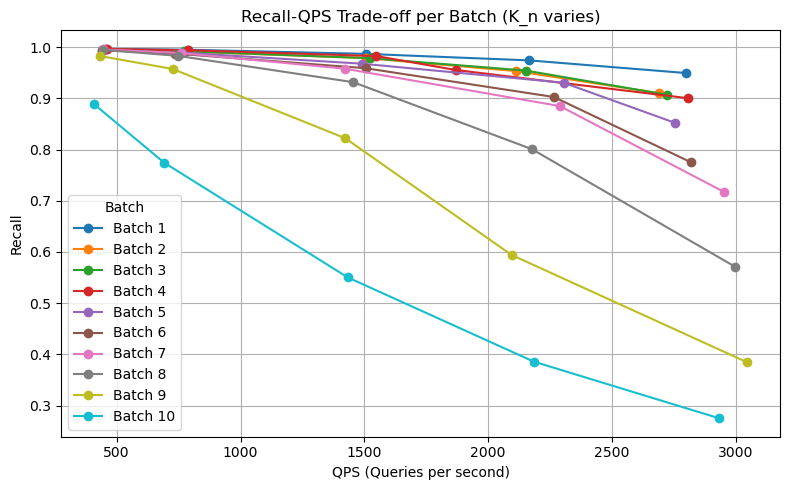

/home/mintaek/hybrid_index/Benchmark/mtg-40K
Post_Hardness


In [7]:
## post filtering graph 그리기

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
colors = plt.cm.tab10.colors  # 10개 batch 색상

num_batches = len(next(iter(trade_off.values())))  # 10개 batch로 가정
k_values = sorted(trade_off.keys())

for batch_idx in range(num_batches):
    qps_list = []
    recall_list = []
    for K in k_values:
        batch_stats = trade_off[K][batch_idx]  # 각 K별 batch_idx번째 dict
        qps_list.append(float(batch_stats['qps']))
        recall_list.append(float(batch_stats['avg_recall']))
    plt.plot(qps_list, recall_list, marker='o', color=colors[batch_idx % 10], label=f'Batch {batch_idx+1}')
    # 점마다 K 표시 원하면
    # for i, K in enumerate(k_values):
    #     plt.text(qps_list[i], recall_list[i], f"{K}", fontsize=8, color=colors[batch_idx % 10])

plt.xlabel("QPS (Queries per second)")
plt.ylabel("Recall")
plt.title(f"Recall-QPS Trade-off per Batch (K_n varies)")
plt.legend(title="Batch")
plt.grid(True)
plt.tight_layout()

pig_path = os.path.join(post_filter_path, f"{sort_hardness}.png")
plt.savefig(pig_path, dpi=300)
plt.show()

print(dataset_path)
print(sort_hardness)

### 아래는 pre filter를 측정하는 코드

In [29]:
# ## pre filtering 측정하기

# from tqdm import tqdm
# import time
# num_batches = len(tests) // 1000 + (1 if len(tests) % 1000 != 0 else 0)
# K = 10
# batch_stats = []
# for batch_idx in tqdm(range(num_batches)):
#     batch_tests = sorted_tests[batch_idx*1000 : (batch_idx+1)*1000]
#     # batch_tests는 Hardness 기준 정렬된 tests의 slice
#     t0 = time.time()
#     batch_results = pre_filtering(vectors, K, batch_tests, payloads, space)
#     t1 = time.time()
#     elapsed = t1 - t0
#     recalls = []
#     for i, test in enumerate(batch_tests):
#         gt_ids = test['closest_ids']  # 혹은 ground-truth id field 이름
#         retrieved_ids = batch_results[i]
#         recalls.append(recall_at_k(retrieved_ids, gt_ids, K))
#     avg_recall = np.mean(recalls)
#     qps = len(batch_tests) / elapsed if elapsed > 0 else 0
#     # print(f"Batch {batch_idx}: QPS={qps:.2f}, Avg Recall@{K}={avg_recall:.4f}, Time={elapsed:.2f}s")
#     batch_stats.append({
#         'batch': batch_idx,
#         'qps': qps,
#         'avg_recall': avg_recall,
#         'elapsed': elapsed,
#         'num_queries': len(batch_tests)
#     })

In [30]:
# ## pre filtering graph 그리기

# import matplotlib.pyplot as plt

# colors = plt.cm.tab10.colors

# plt.figure(figsize=(14, 7))

# for d in batch_stats:
#     plt.scatter(float(d['qps']), float(d['avg_recall']), color=colors[d['batch'] % 10], s=100, label=f'Batch {d["batch"]+1}')

# handles, labels = plt.gca().get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# plt.legend(
#     by_label.values(),
#     by_label.keys(),
#     # title="Batch",
#     loc='upper right',
#     fontsize=10,  # ★ 여기서 폰트 사이즈 조절
#     ncol=10   # ★ legend를 1행으로 만듦 (batch가 10개니까 ncol=10)
# )

# plt.xlabel("QPS")
# plt.ylabel("Recall")
# plt.title("Recall vs QPS (per Batch)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()
